In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('fraud_oracle.csv')
df.sample(5)

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
3354,Oct,3,Monday,Honda,Urban,Thursday,Oct,3,Female,Single,...,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,All Perils
2889,Sep,4,Thursday,Pontiac,Rural,Tuesday,Sep,4,Male,Single,...,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,All Perils
13401,Jun,2,Monday,Toyota,Urban,Tuesday,Jun,3,Male,Married,...,7 years,41 to 50,No,No,External,more than 5,no change,1 vehicle,1996,Liability
7763,Jul,1,Monday,Pontiac,Urban,Monday,Jul,1,Male,Single,...,more than 7,41 to 50,No,No,External,more than 5,no change,1 vehicle,1995,Collision
10187,Dec,3,Monday,Mazda,Urban,Tuesday,Feb,1,Female,Single,...,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1995,Liability


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [3]:
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

In [4]:
num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(exclude=np.number).columns

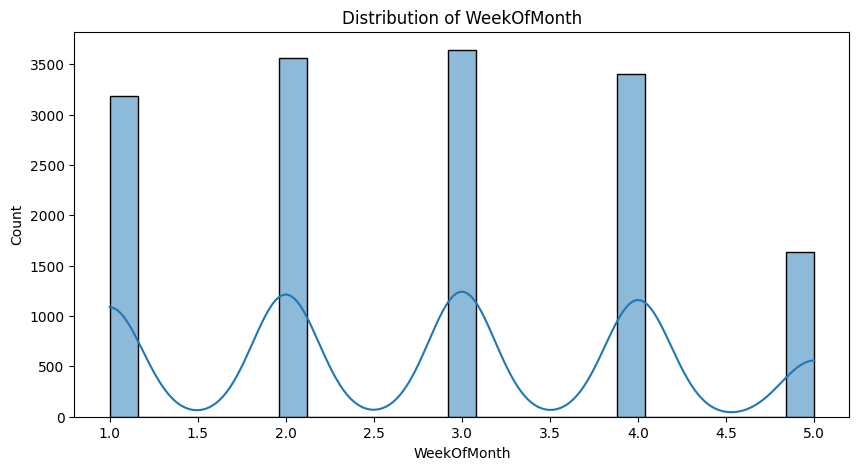

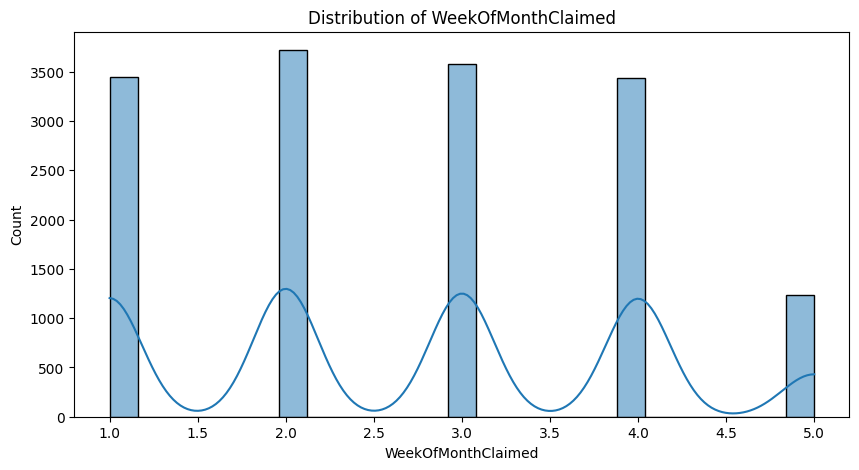

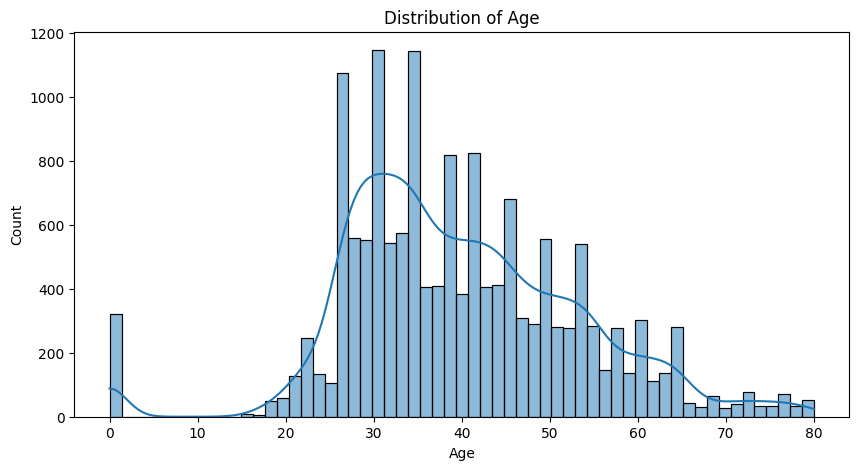

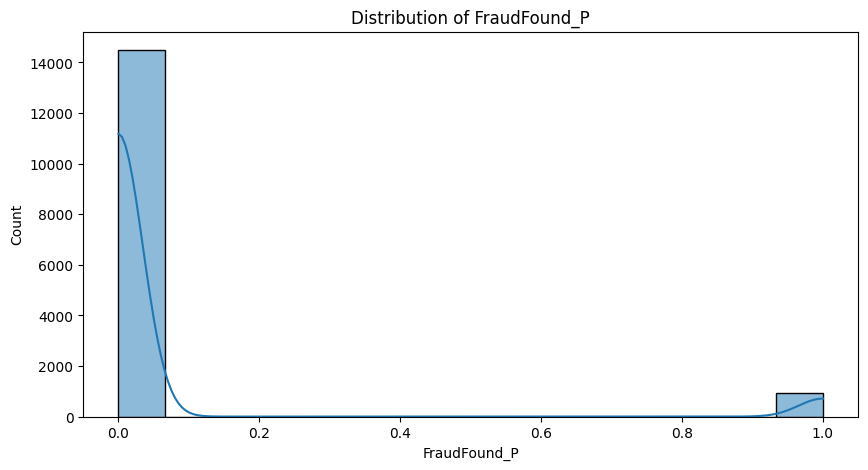

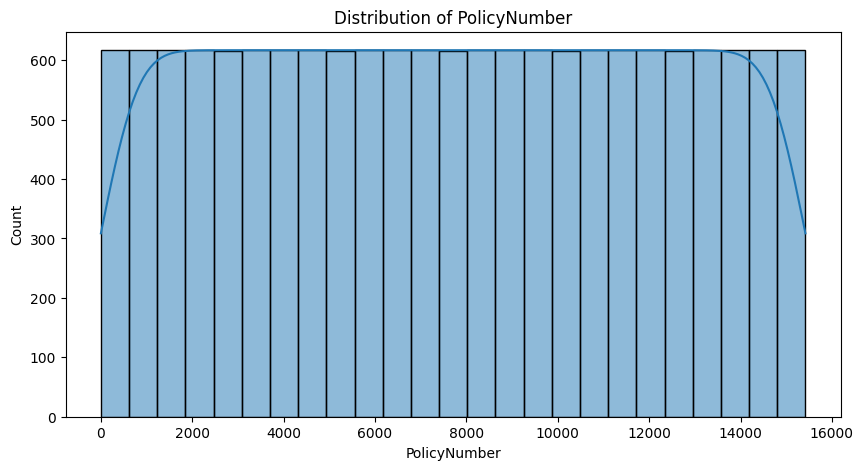

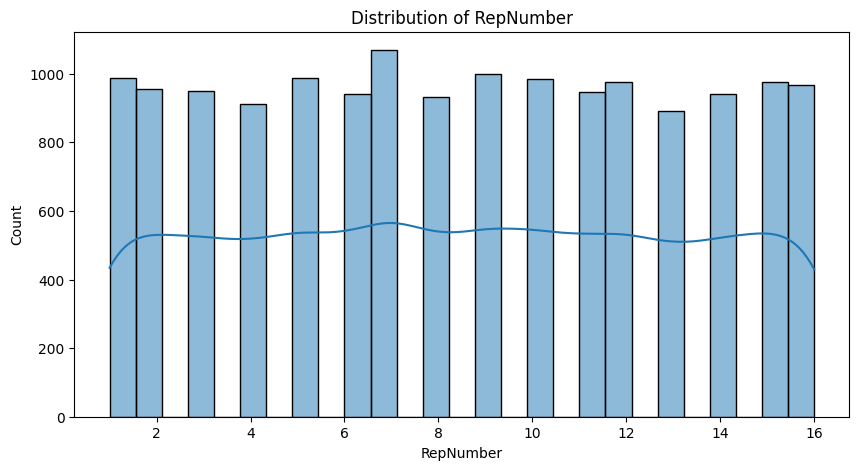

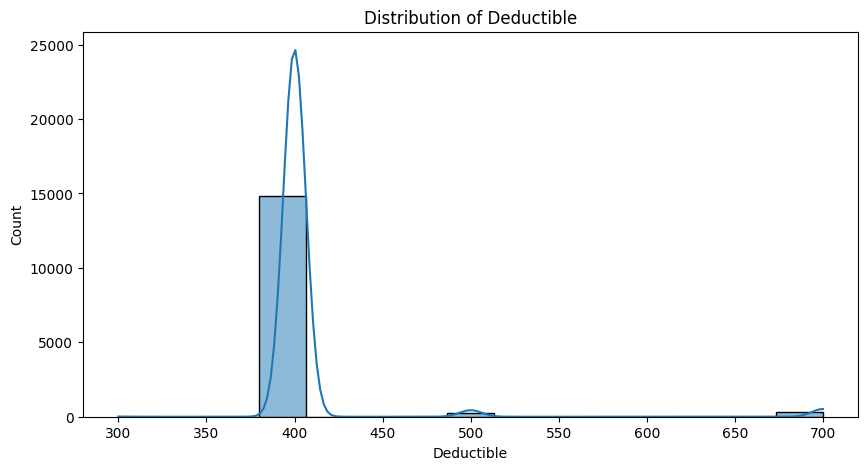

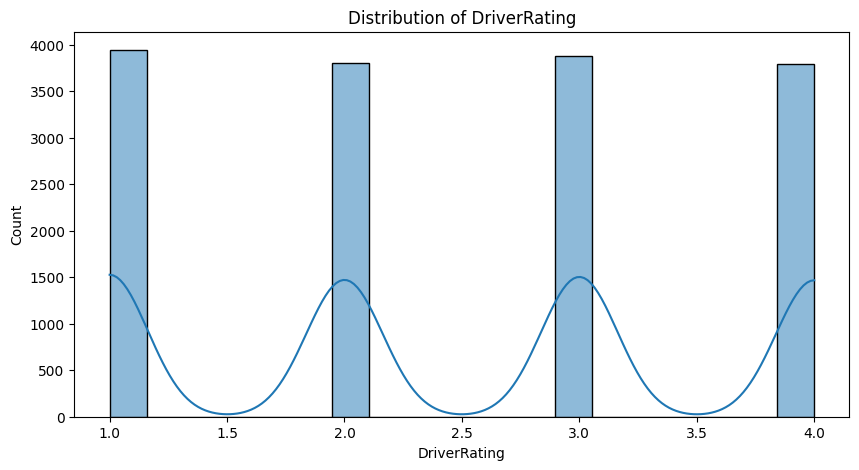

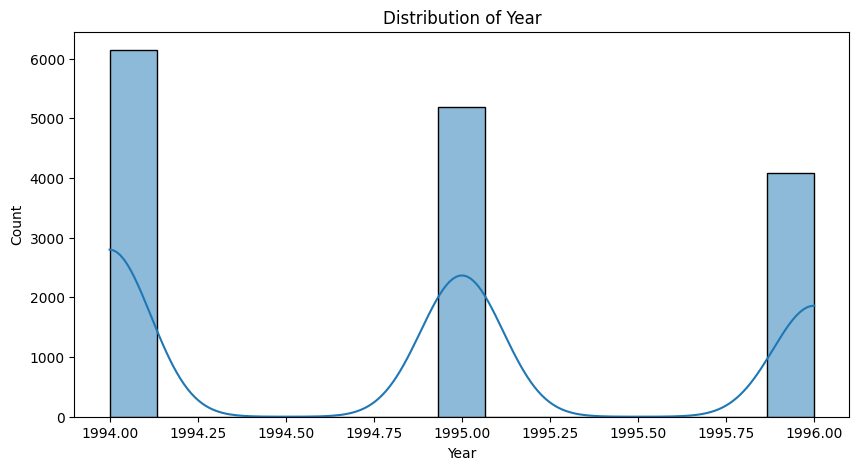

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in num_cols:
    plt.figure(figsize=(10,5))
    sns.histplot(data=df,x=col,kde=True)
    plt.title(f'Distribution of {col}')

C:\Users\Asus\AppData\Local\Temp\ipykernel_20528\958586486.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,5))


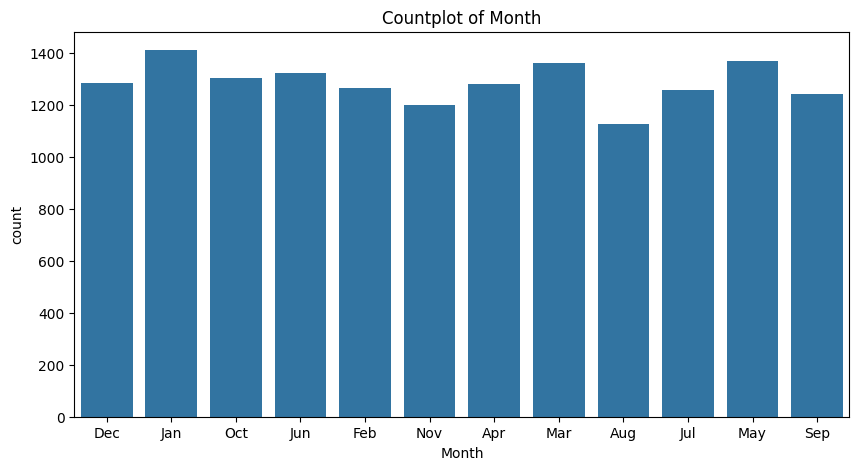

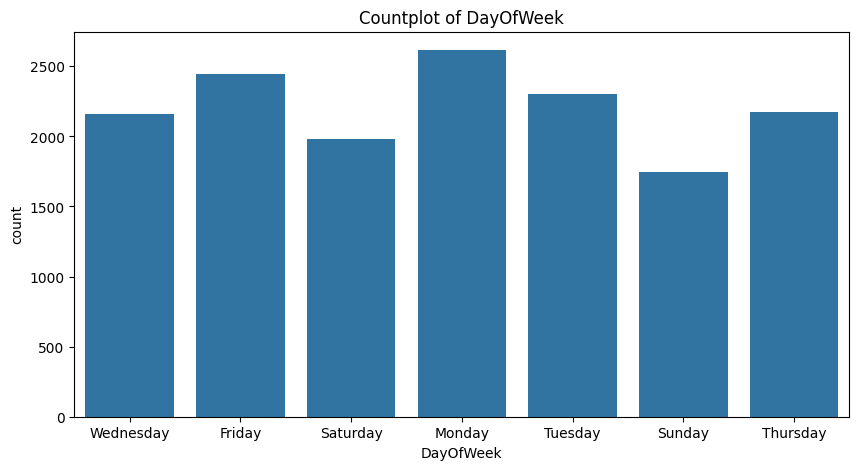

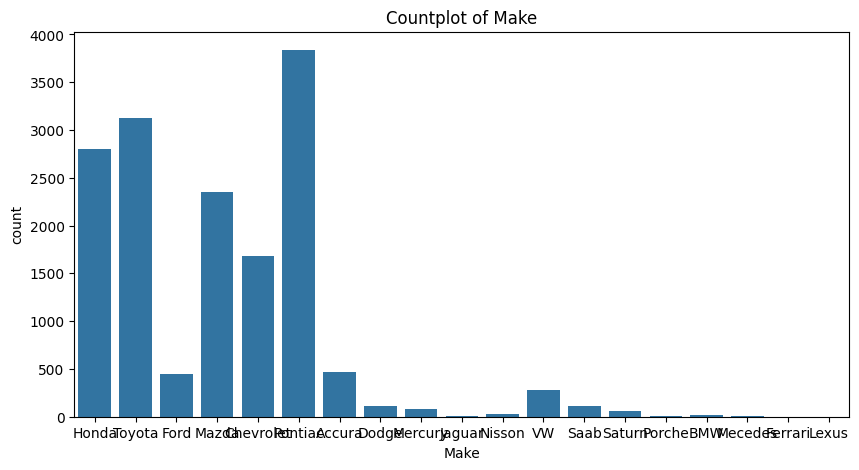

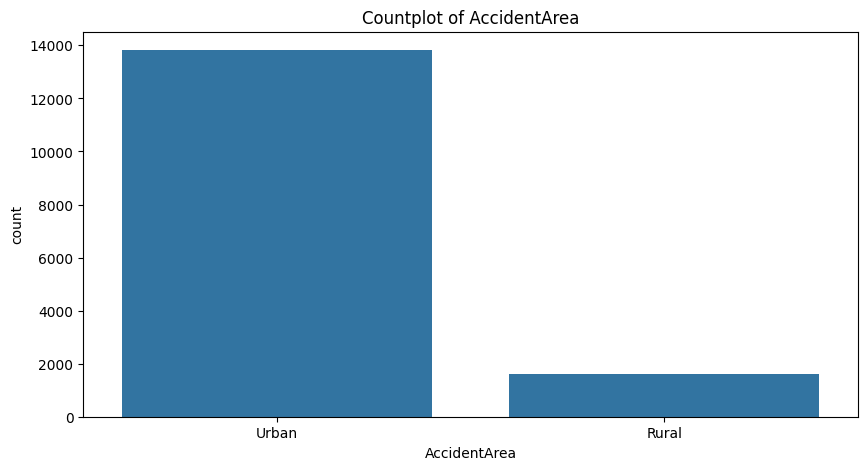

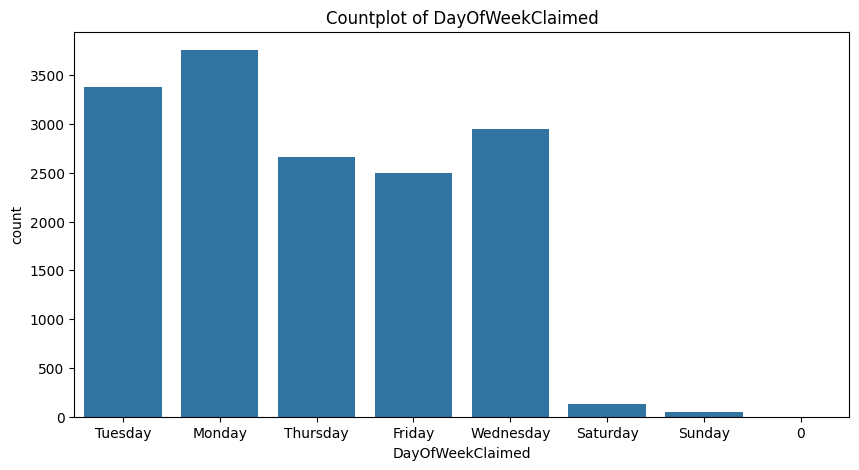

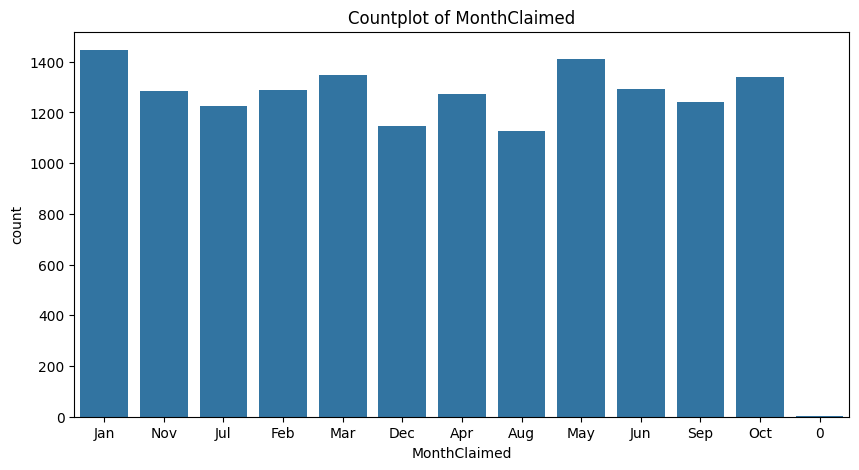

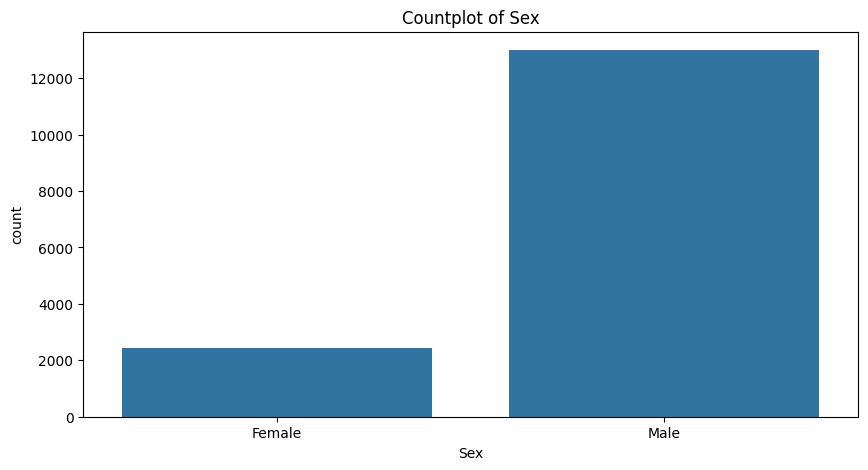

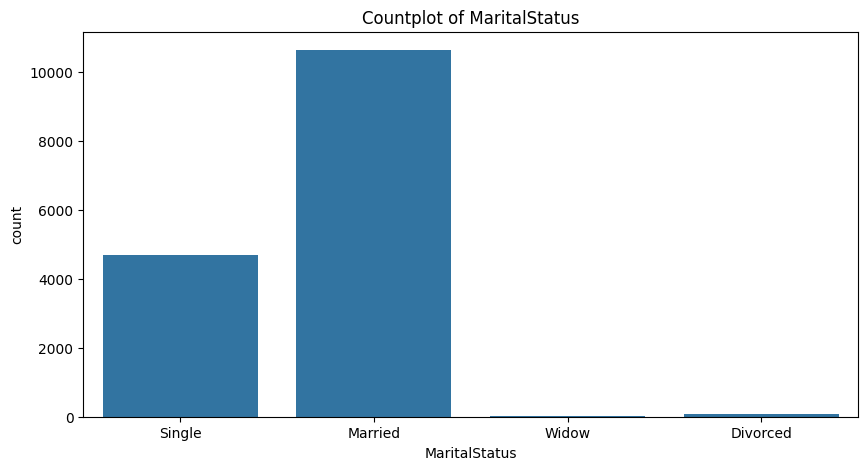

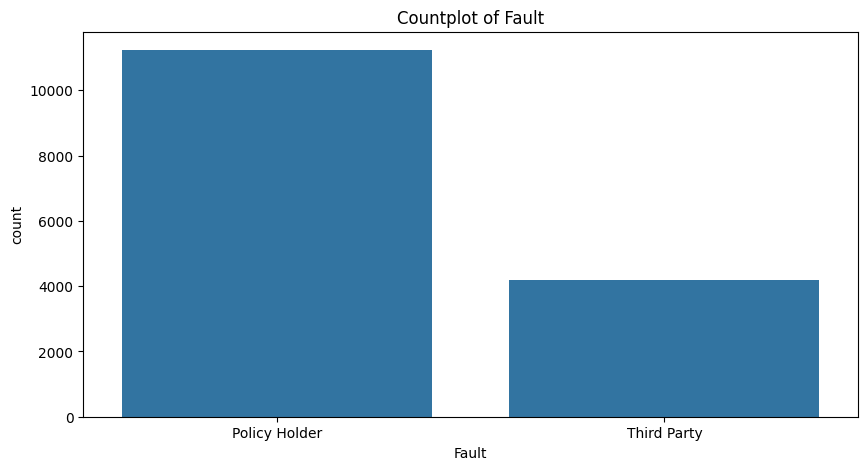

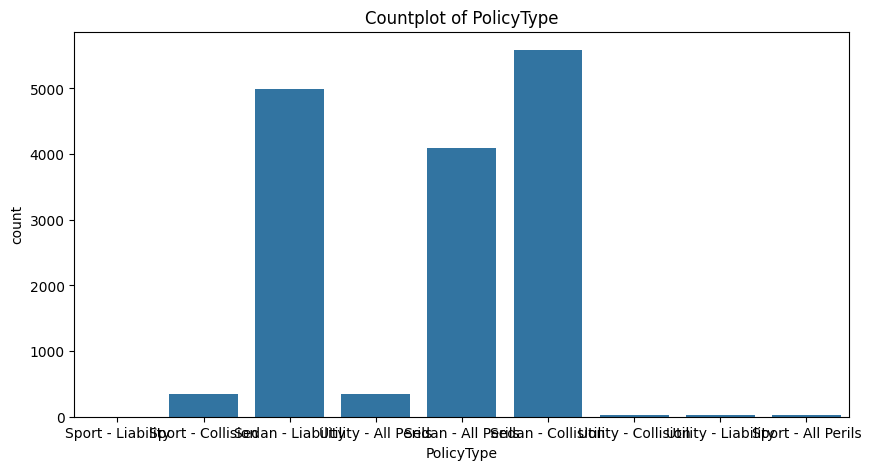

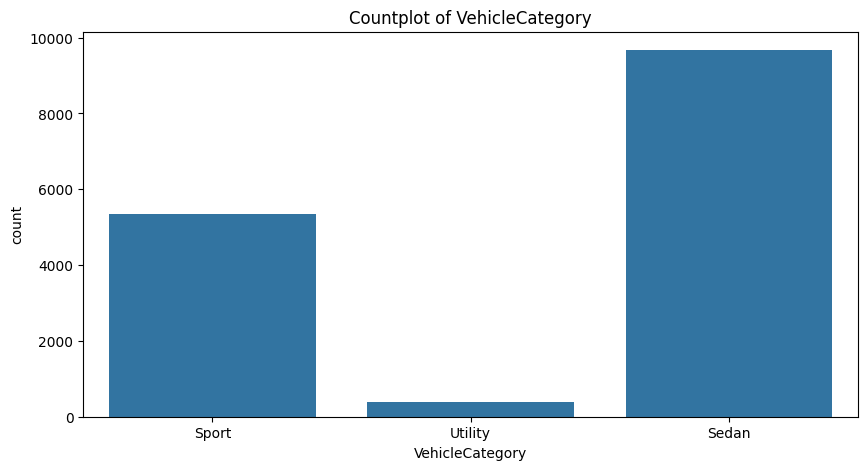

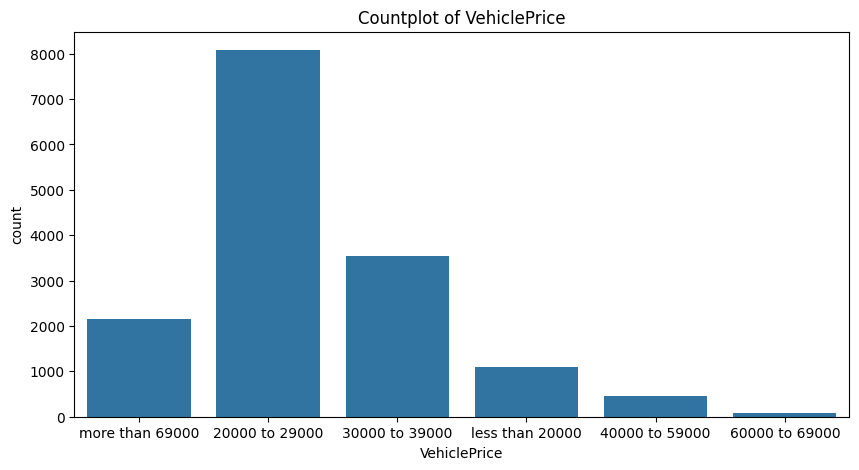

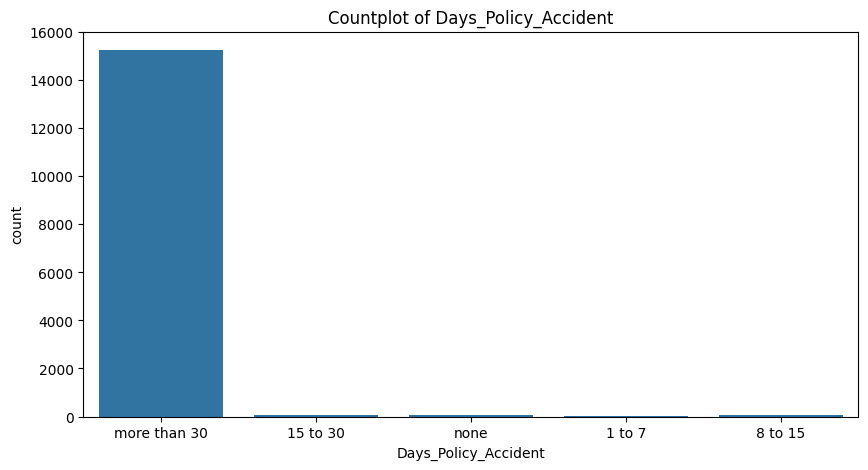

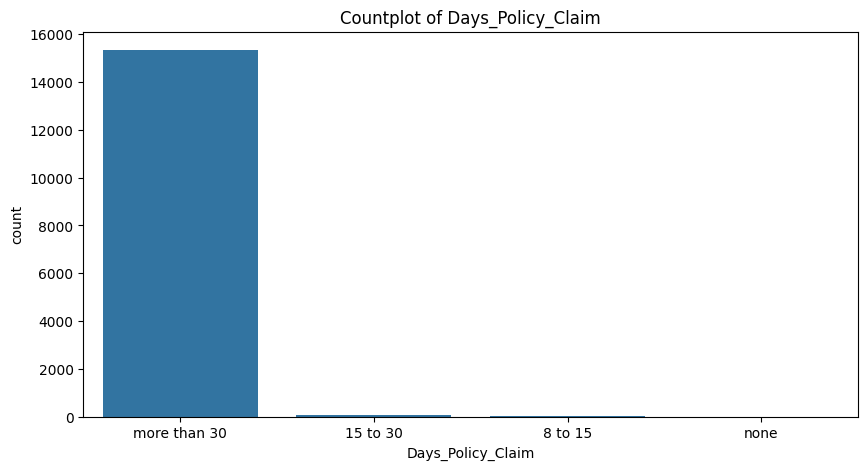

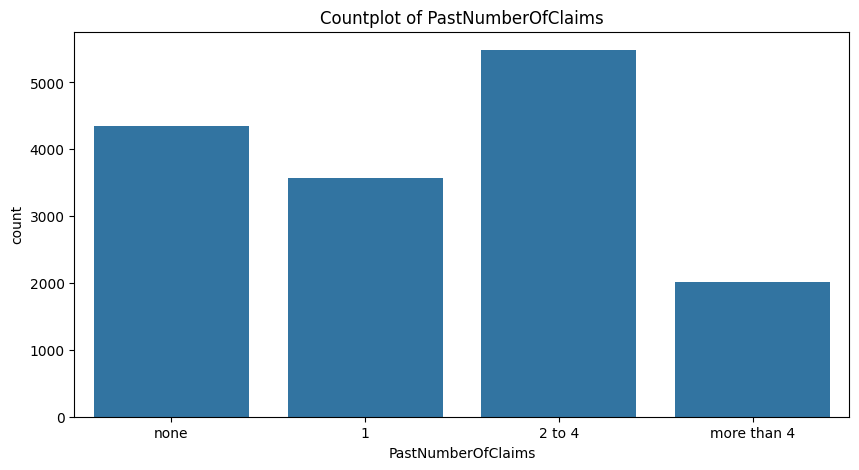

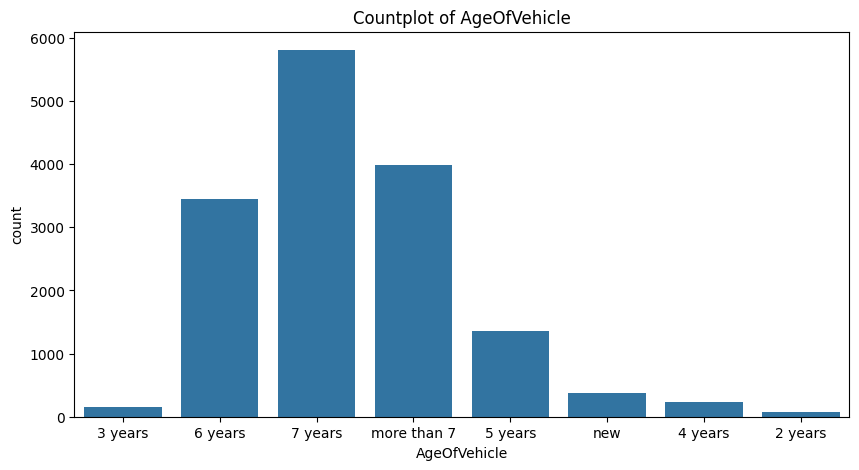

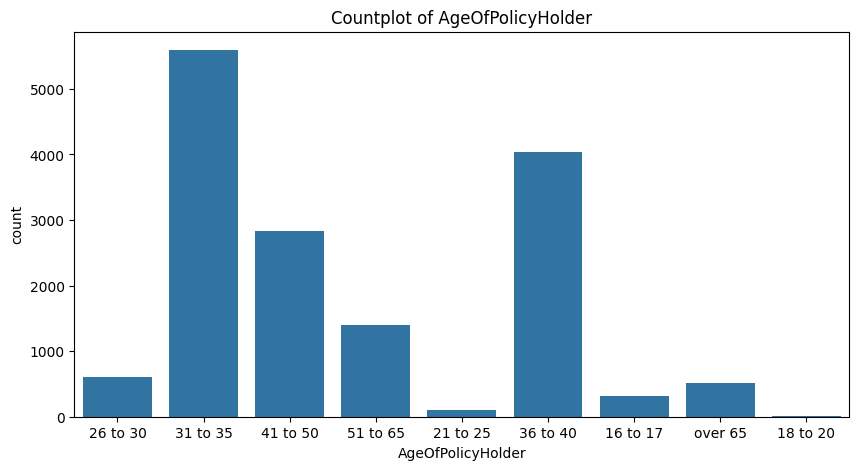

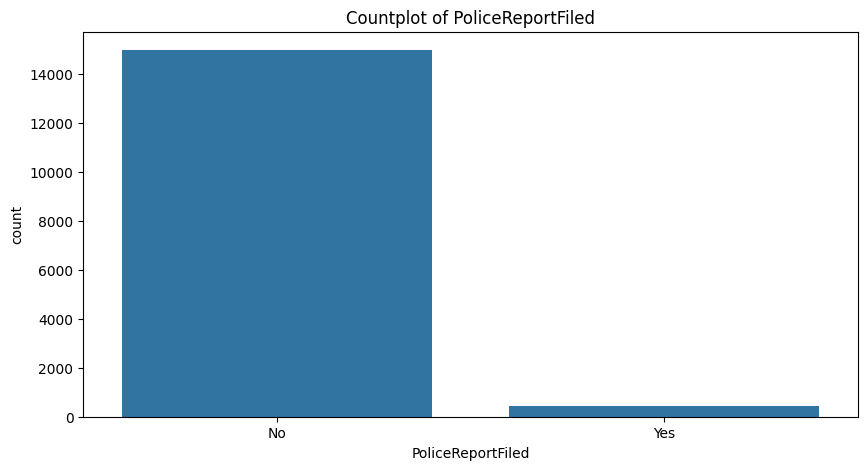

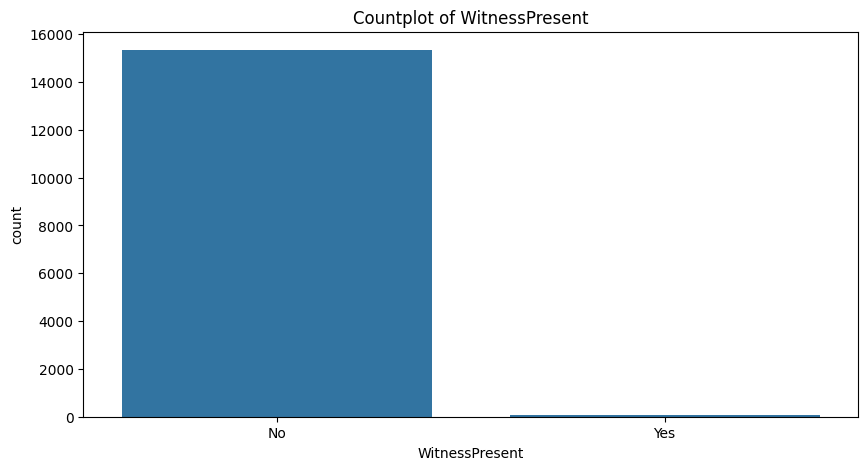

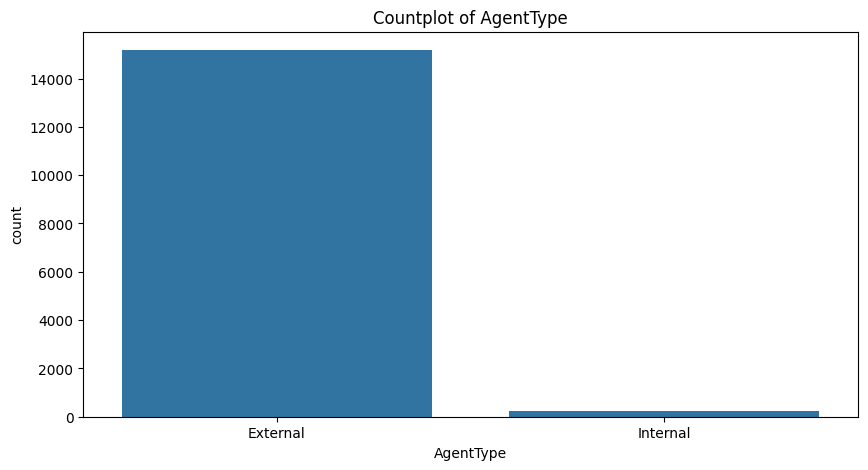

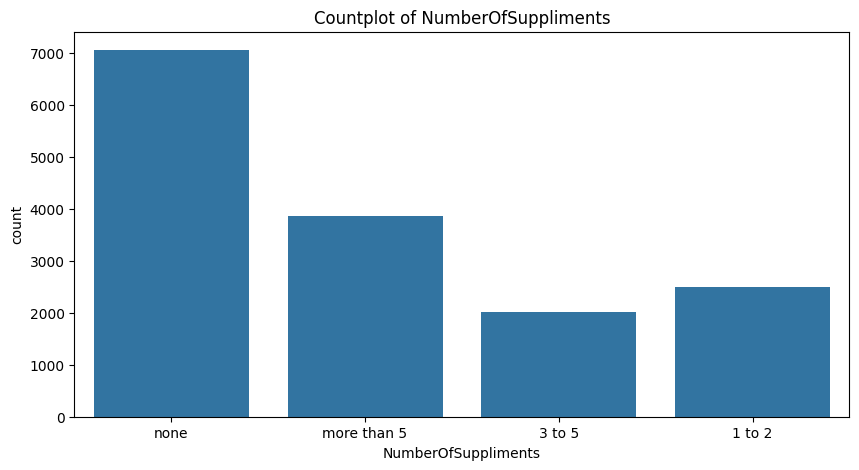

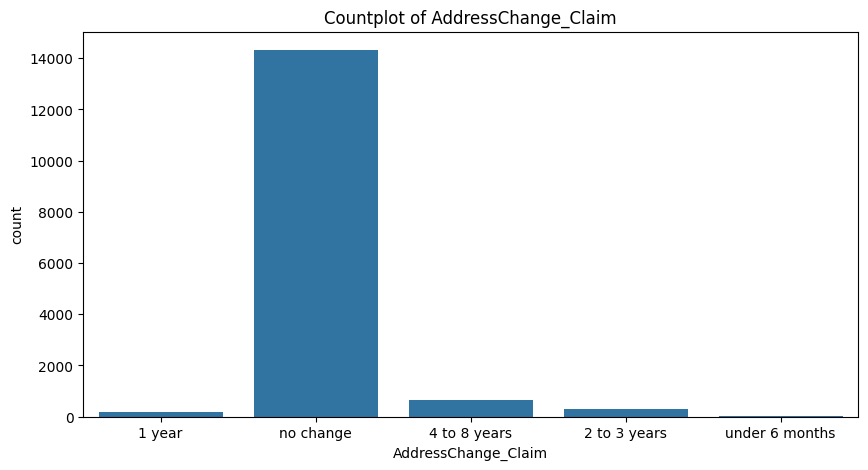

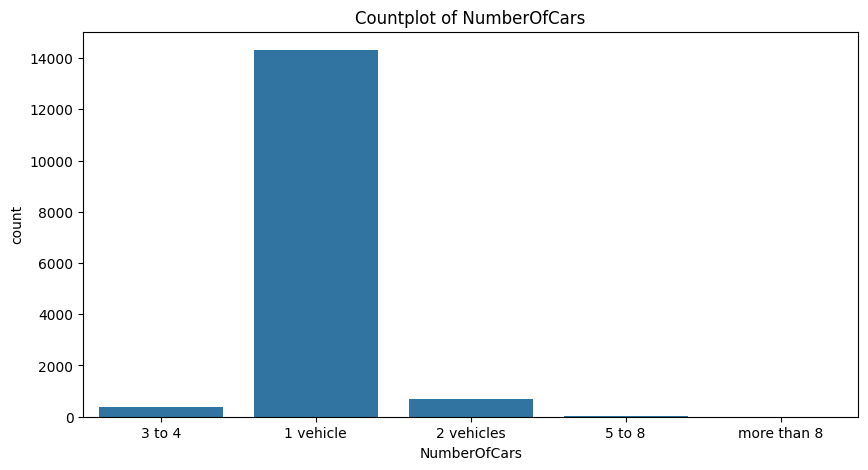

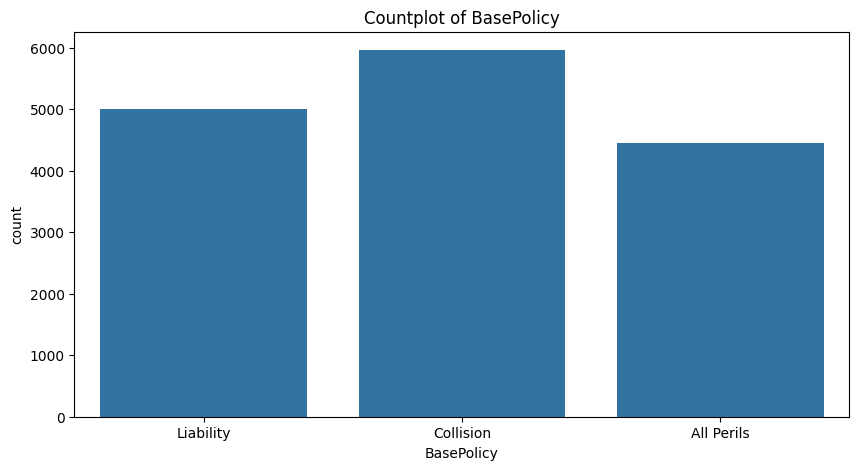

In [6]:
for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df,x=col)
    plt.title(f'Countplot of {col}')

In [7]:
df.duplicated().sum()

0

In [8]:
df['FraudFound_P'].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

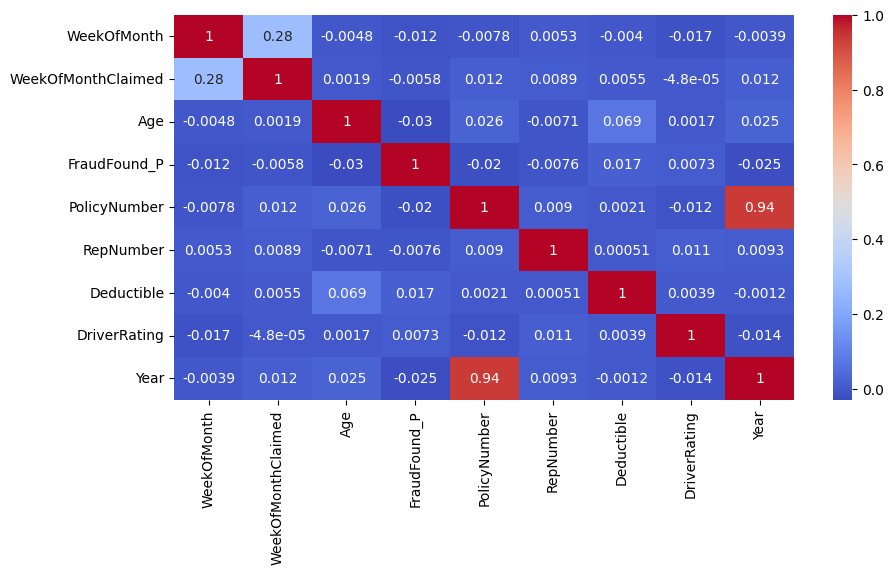

In [9]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

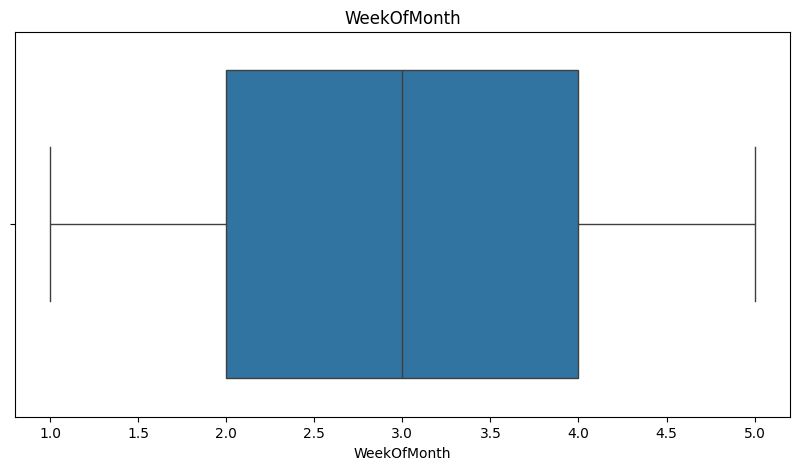

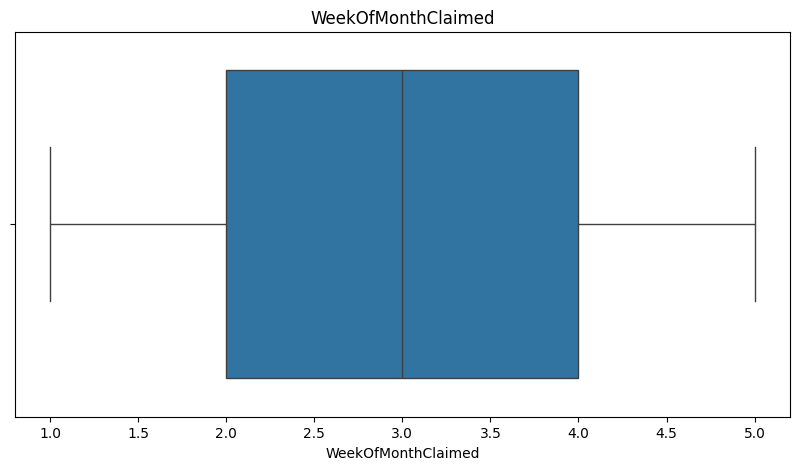

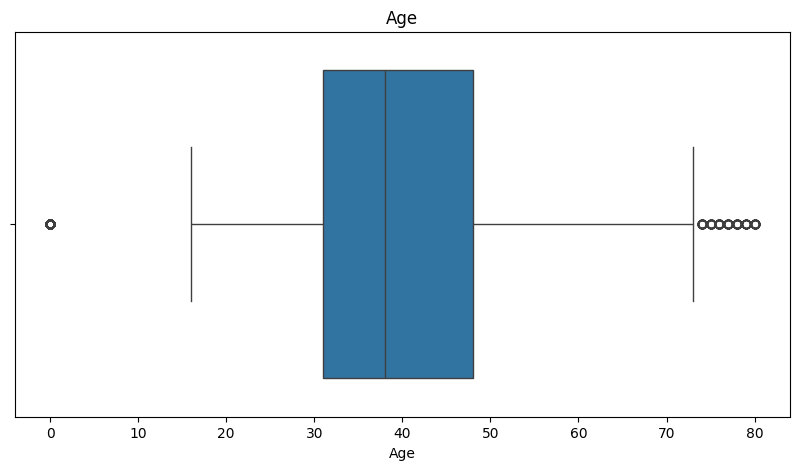

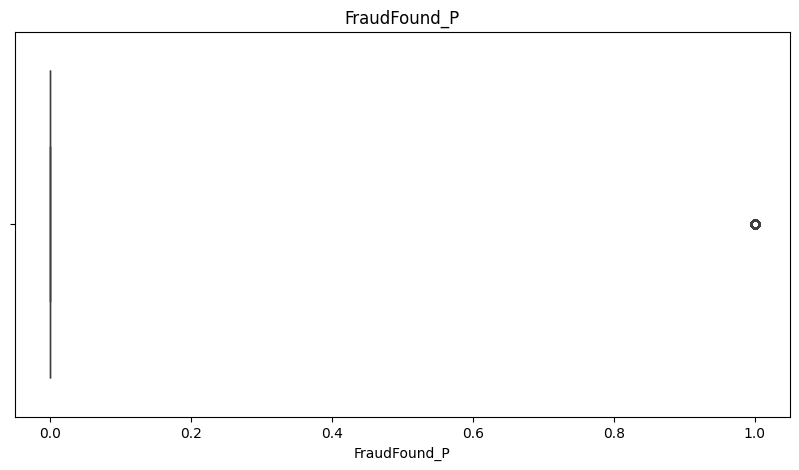

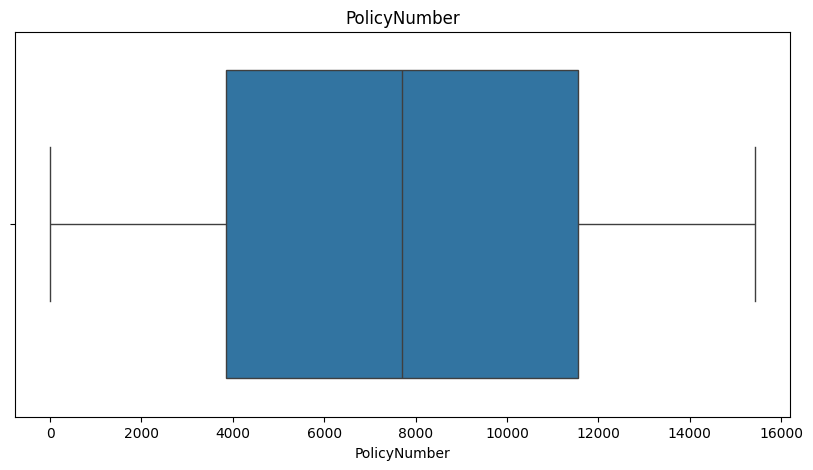

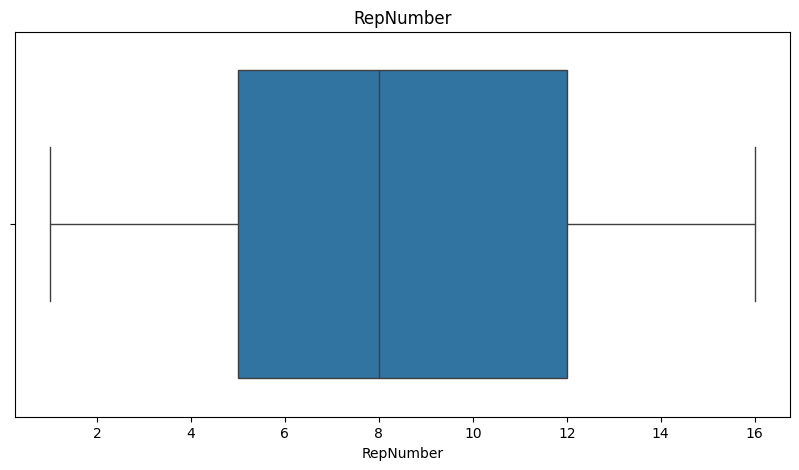

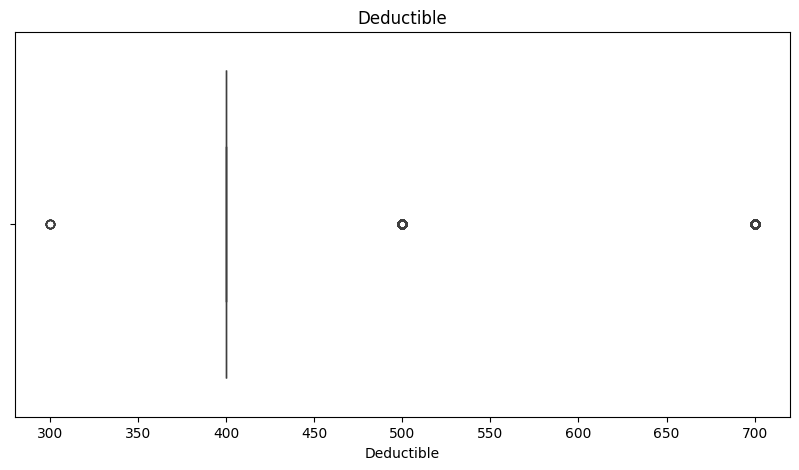

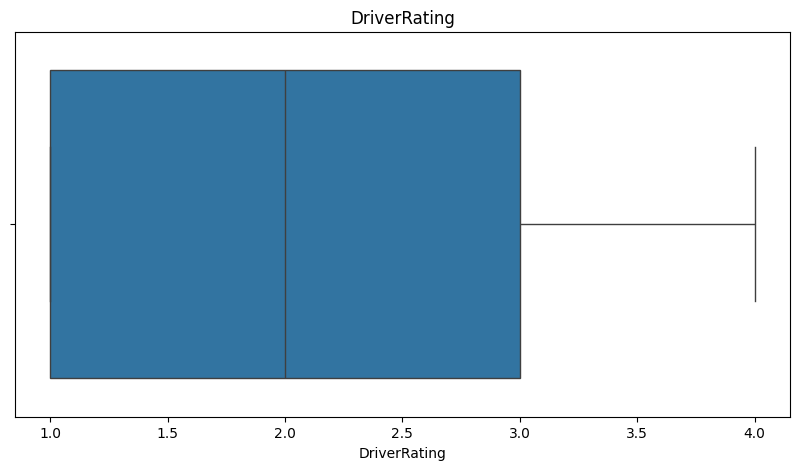

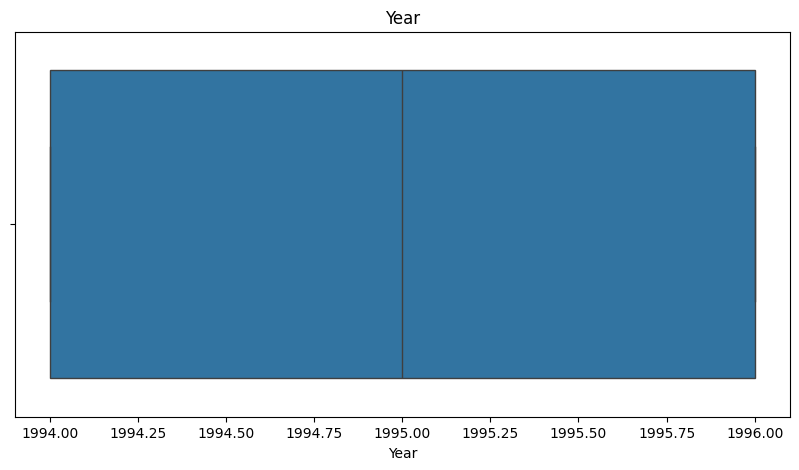

In [10]:
for col in num_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [11]:
df.columns.tolist()

['Month',
 'WeekOfMonth',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'WeekOfMonthClaimed',
 'Sex',
 'MaritalStatus',
 'Age',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'FraudFound_P',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'Year',
 'BasePolicy']

C:\Users\Asus\AppData\Local\Temp\ipykernel_20528\3700860780.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,5))


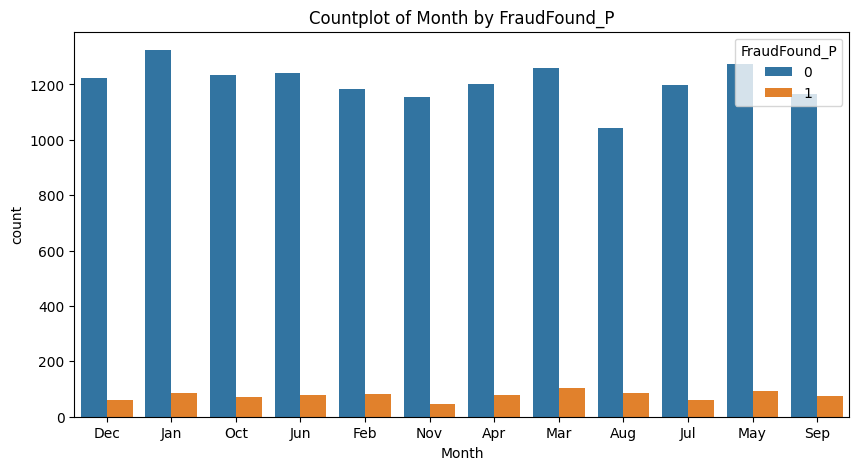

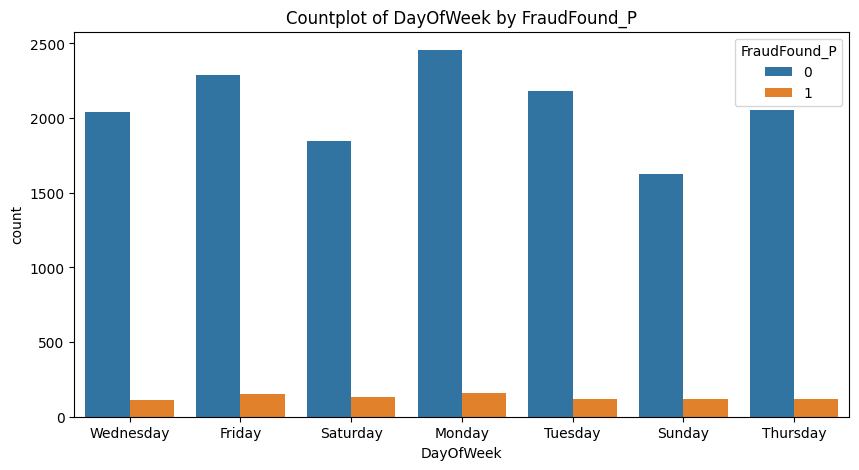

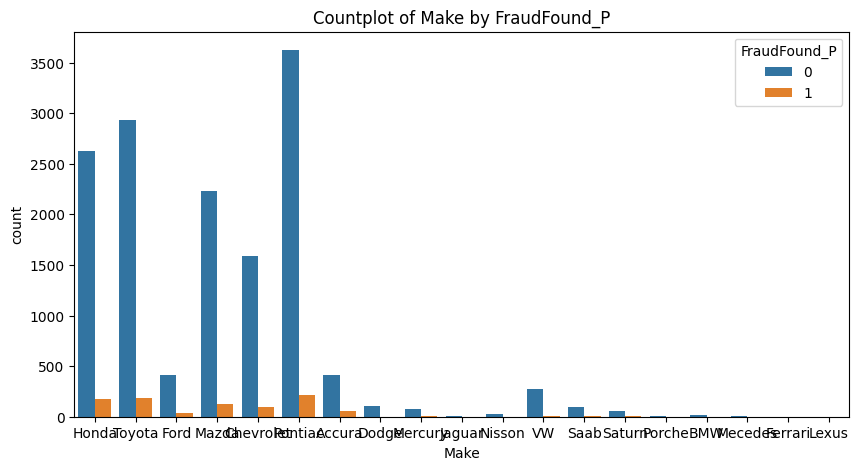

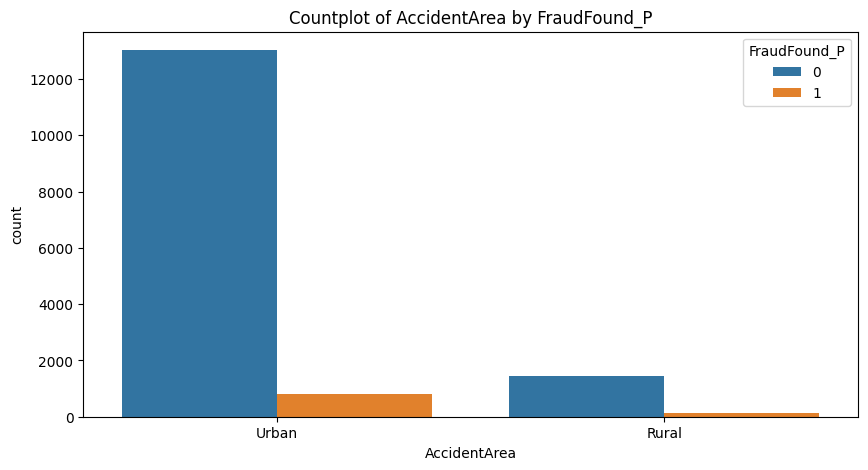

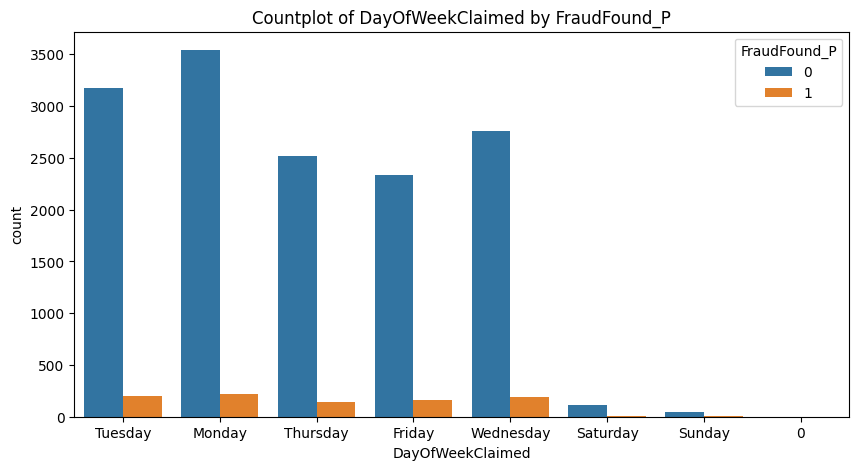

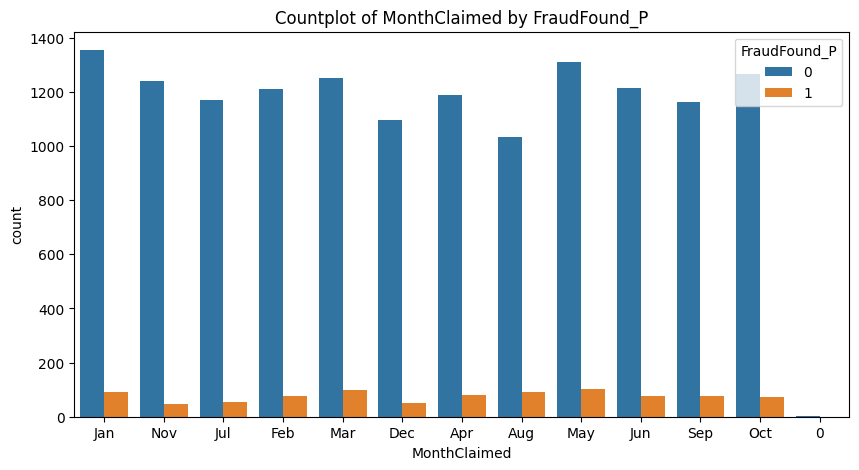

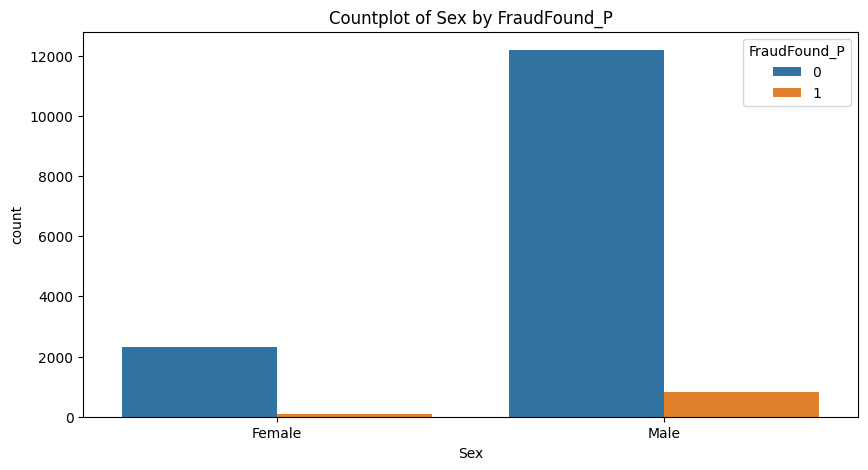

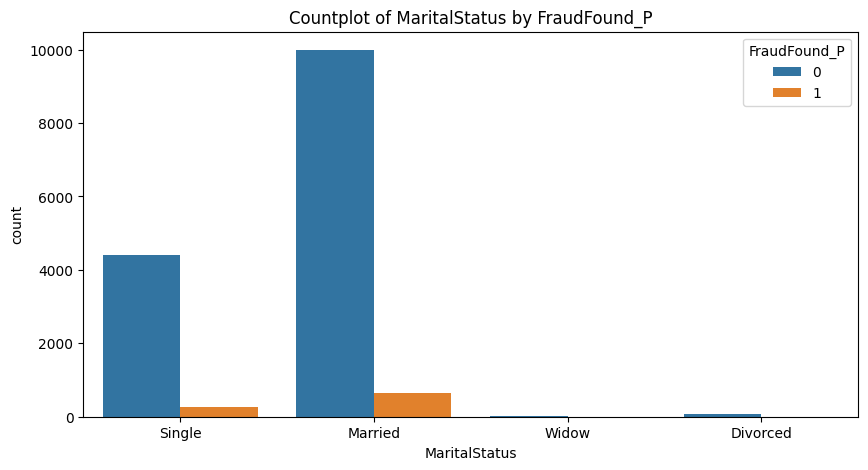

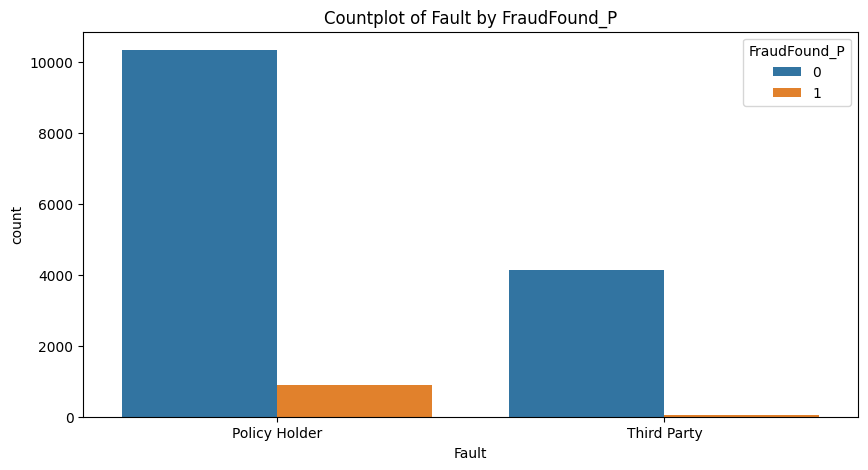

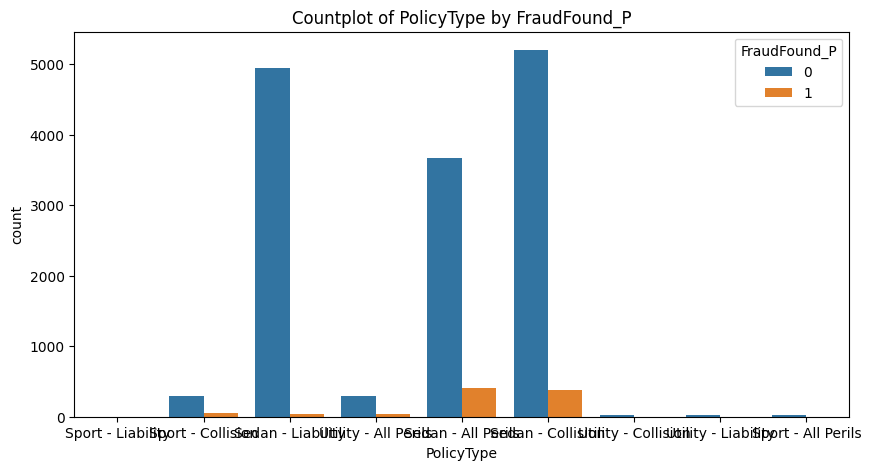

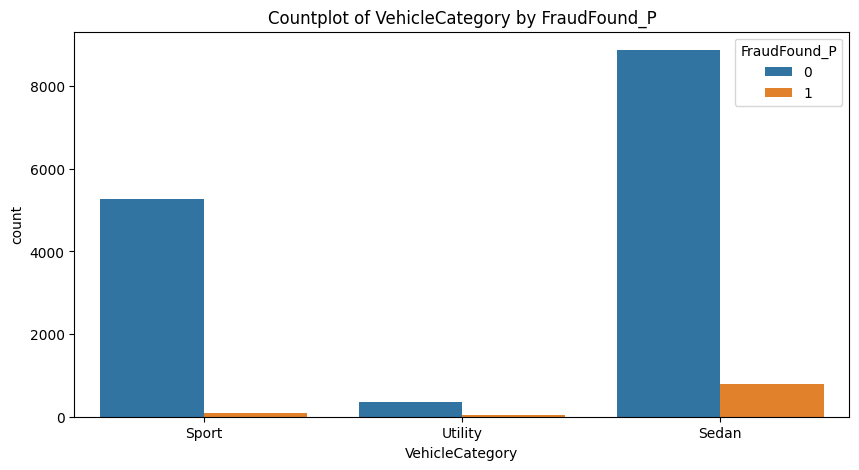

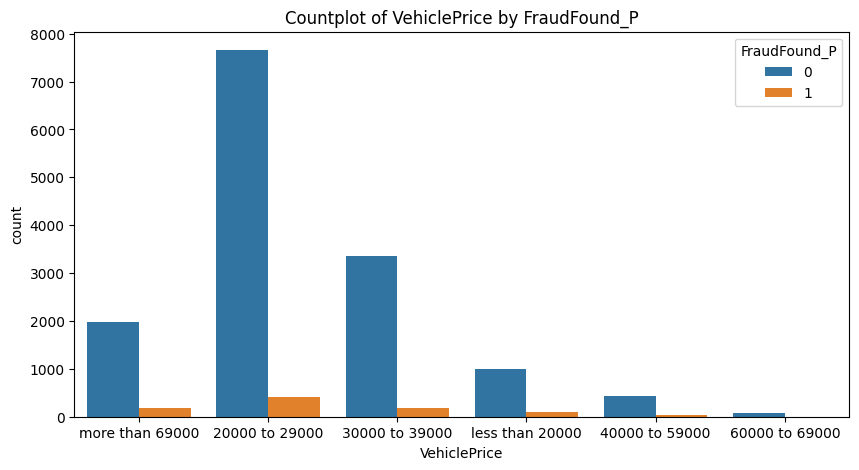

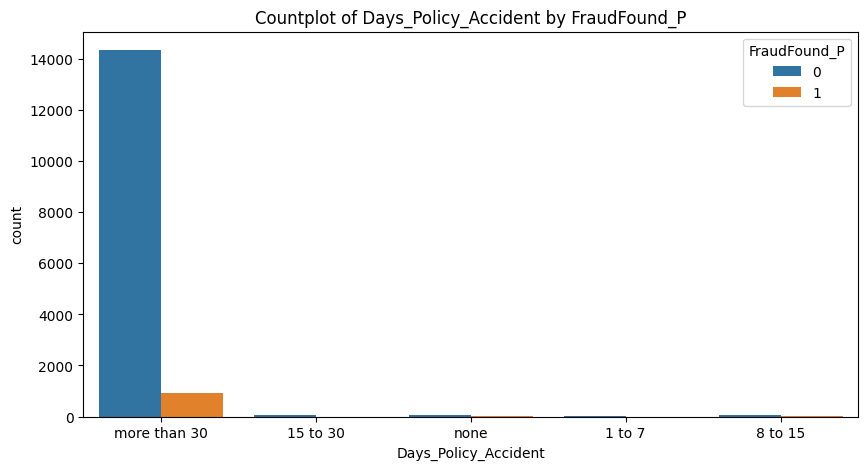

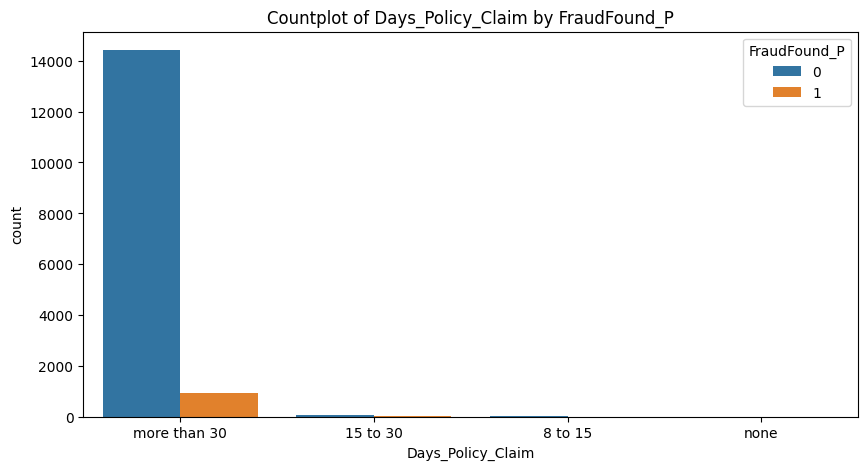

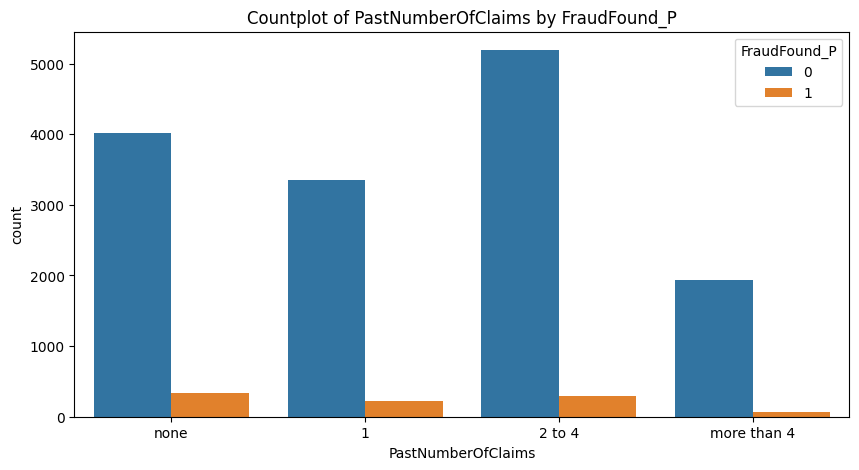

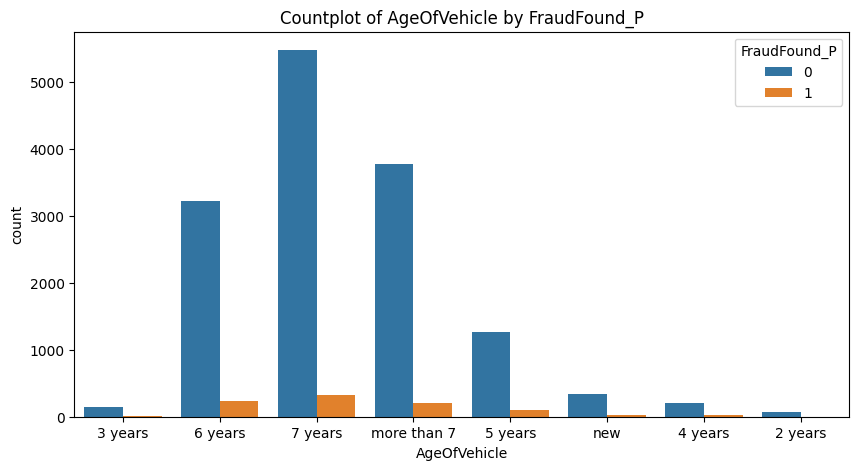

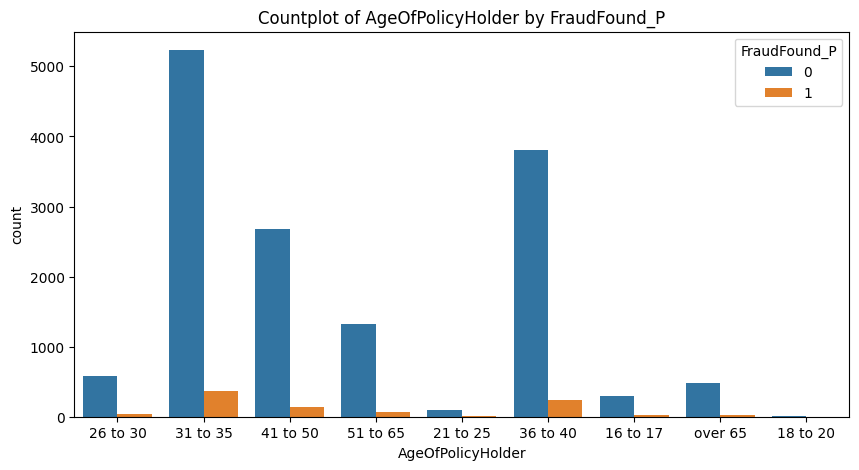

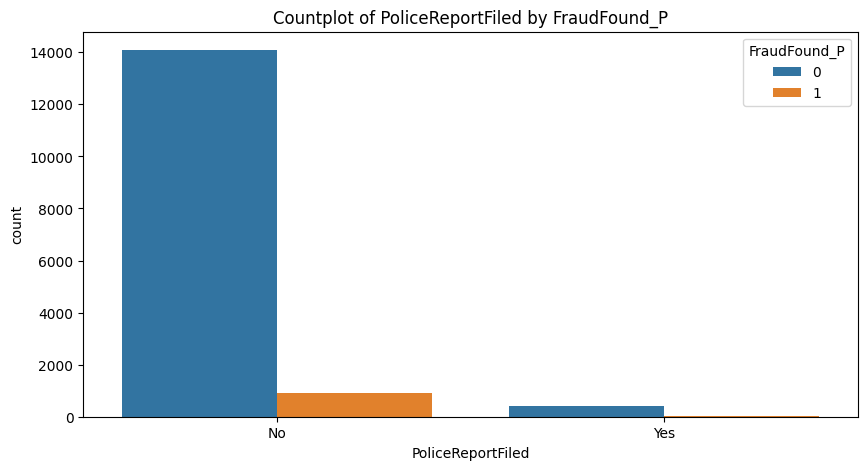

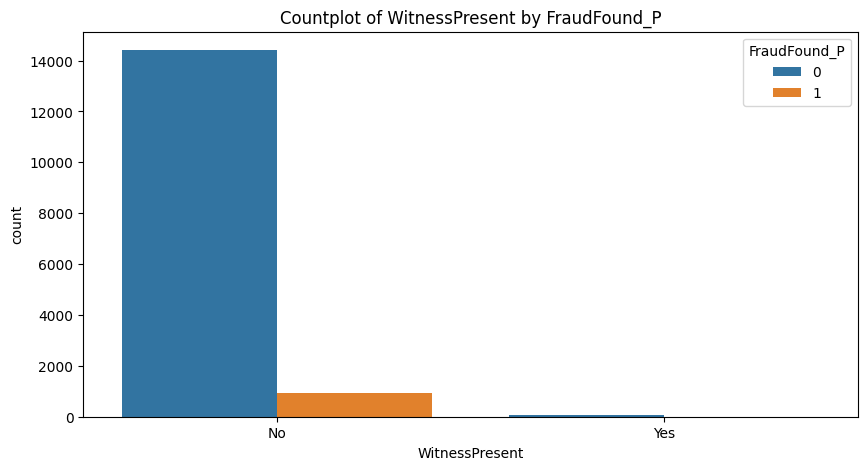

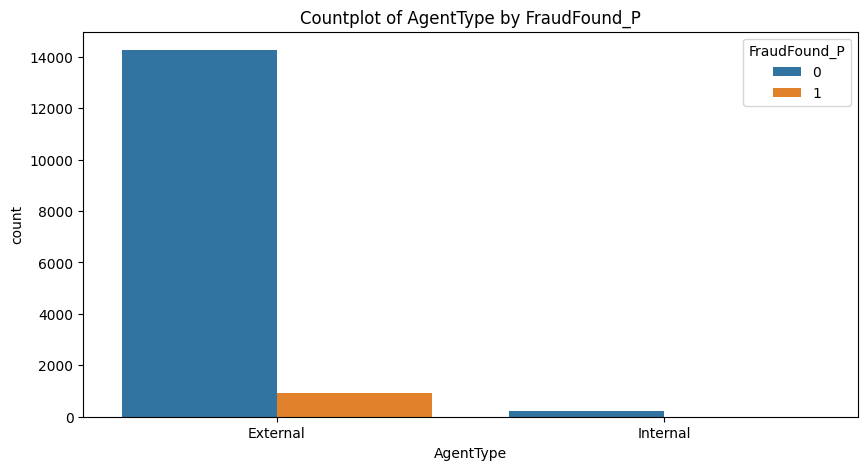

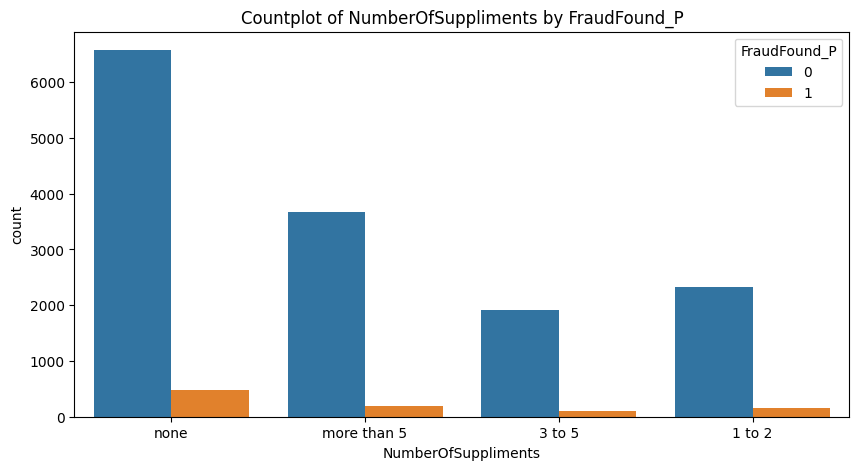

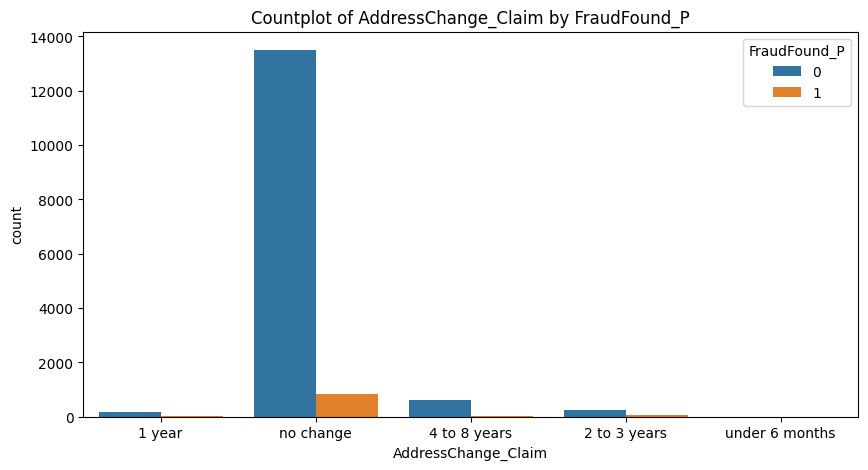

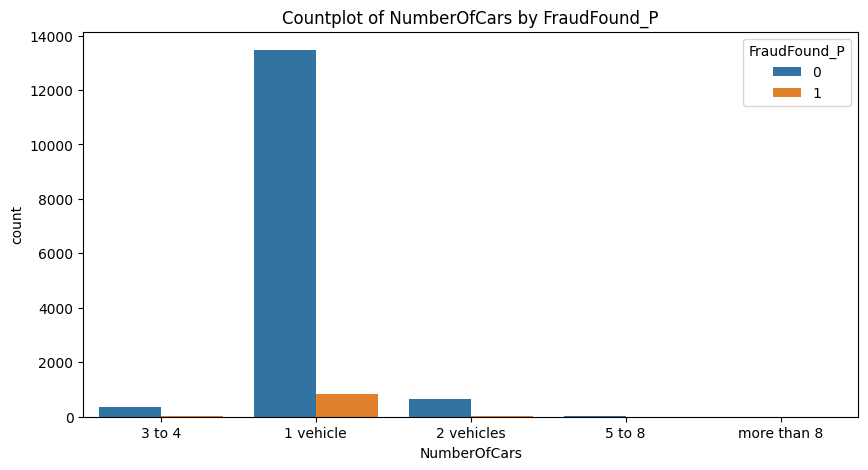

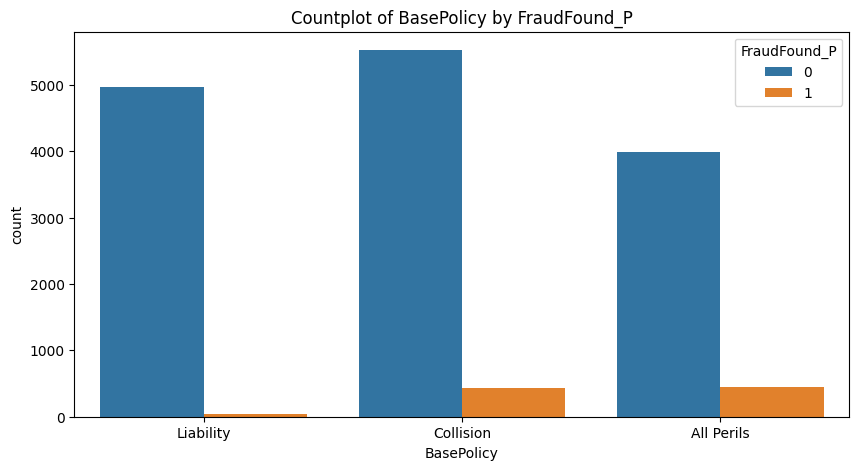

In [12]:
for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df,x=col,hue='FraudFound_P')
    plt.title(f'Countplot of {col} by FraudFound_P')

In [13]:
for col in cat_cols:
    print(f"\n{col}")
    print(pd.crosstab(df[col],df['FraudFound_P'],normalize='index'))


Month
FraudFound_P         0         1
Month                           
Apr           0.937500  0.062500
Aug           0.925466  0.074534
Dec           0.951751  0.048249
Feb           0.935229  0.064771
Jan           0.938342  0.061658
Jul           0.952267  0.047733
Jun           0.939440  0.060560
Mar           0.925000  0.075000
May           0.931236  0.068764
Nov           0.961699  0.038301
Oct           0.946360  0.053640
Sep           0.938710  0.061290

DayOfWeek
FraudFound_P         0         1
DayOfWeek                       
Friday        0.937014  0.062986
Monday        0.938838  0.061162
Saturday      0.933401  0.066599
Sunday        0.930086  0.069914
Thursday      0.944777  0.055223
Tuesday       0.947826  0.052174
Wednesday     0.946735  0.053265

Make
FraudFound_P         0         1
Make                            
Accura        0.875000  0.125000
BMW           0.933333  0.066667
Chevrolet     0.944081  0.055919
Dodge         0.981651  0.018349
Ferrari       1.000

In [14]:
df["AddressChange_Claim"].value_counts()

AddressChange_Claim
no change         14324
4 to 8 years        631
2 to 3 years        291
1 year              170
under 6 months        4
Name: count, dtype: int64

In [15]:
df["Make"].value_counts()

Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64

In [16]:
for col in cat_cols:
    print(df[col].value_counts())
    print("\n")

Month
Jan    1411
May    1367
Mar    1360
Jun    1321
Oct    1305
Dec    1285
Apr    1280
Feb    1266
Jul    1257
Sep    1240
Nov    1201
Aug    1127
Name: count, dtype: int64


DayOfWeek
Monday       2616
Friday       2445
Tuesday      2300
Thursday     2173
Wednesday    2159
Saturday     1982
Sunday       1745
Name: count, dtype: int64


Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64


AccidentArea
Urban    13822
Rural     1598
Name: count, dtype: int64


DayOfWeekClaimed
Monday       3757
Tuesday      3375
Wednesday    2951
Thursday     2660
Friday       2497
Saturday      127
Sunday         52
0               1
Name: count, dtype: int64


MonthClaimed
Jan    144

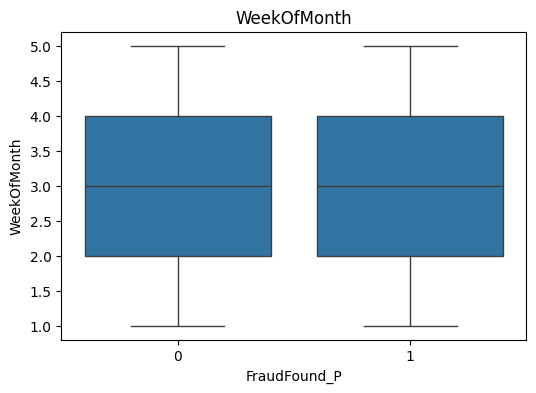

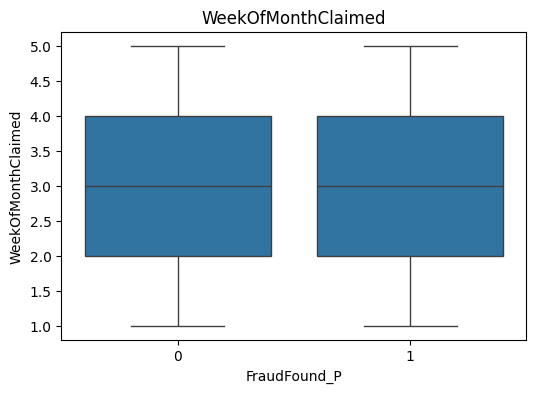

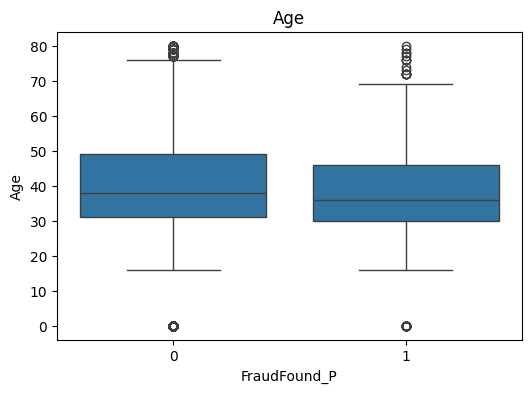

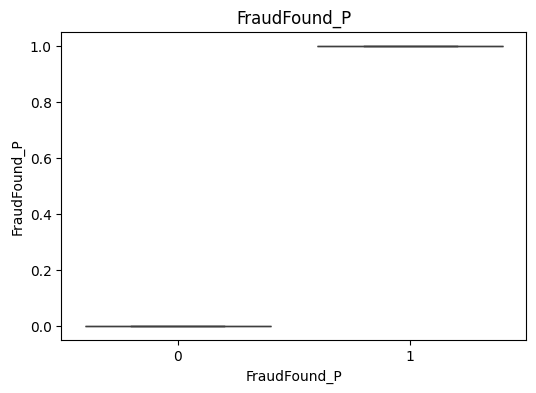

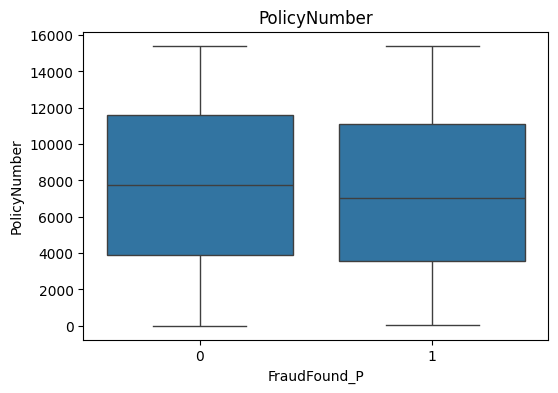

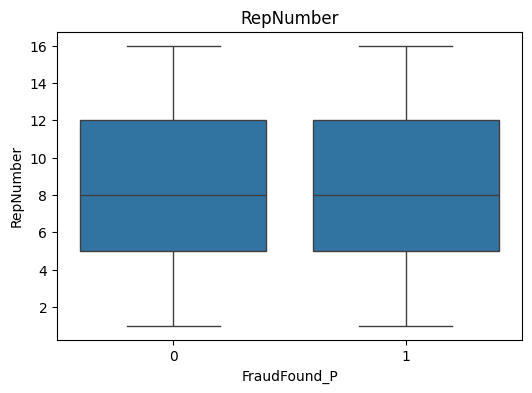

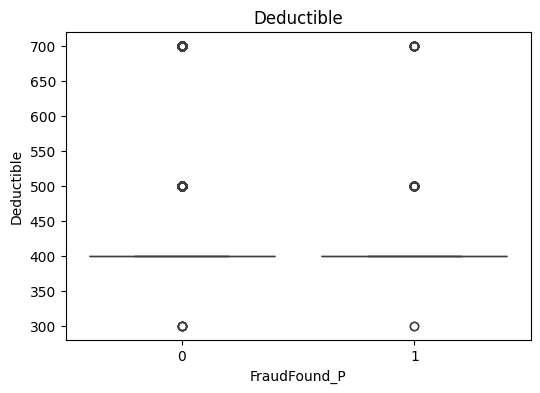

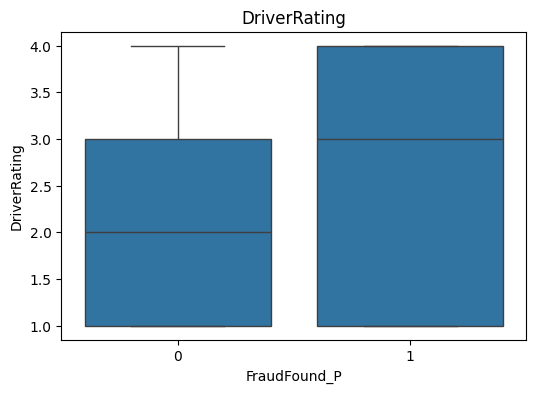

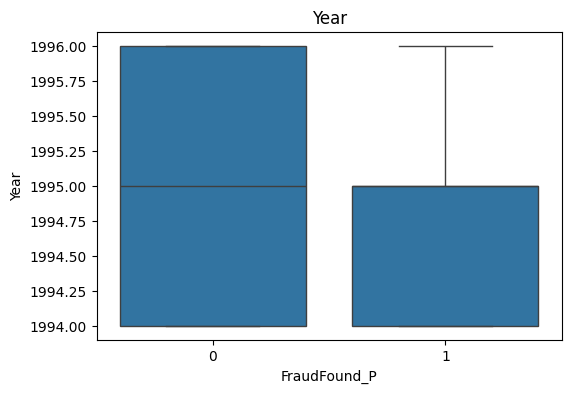

In [17]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="FraudFound_P", y=col, data=df)
    plt.title(col)
    plt.show()

In [18]:
# WeekOfMonth:
# Distribution is nearly identical for fraud and non-fraud claims.
# No clear relationship with the target variable.

# WeekOfMonthClaimed:
# Similar distribution across both classes.
# Does not appear to influence fraud.

# Age:
# Age distribution is similar for both fraud and genuine claims.
# No significant visual difference observed.

# PolicyNumber:
# Acts as an identifier rather than a predictive feature.
# Can be removed during preprocessing.

# RepNumber:
# Similar median and spread for both classes.
# No noticeable relationship with fraud.

# Deductible:
# Only a few discrete values are present.
# Distribution is almost identical for both classes.

# DriverRating:
# Fraud cases show a slightly higher median driver rating.
# May provide some predictive information.

# Year:
# Very little variation across classes.
# No meaningful relationship with fraud.

# FraudFound_P:
# Target variable (ignore for boxplot analysis).

In [19]:
# EDA Summary:
# 1. Fault, VehicleCategory, AccidentArea, BasePolicy and PolicyType
#    show a noticeable relationship with fraud.
#
# 2. DriverRating shows a slight difference and may contribute to prediction.
#
# 3. WeekOfMonth, WeekOfMonthClaimed, Age, RepNumber, Deductible and Year
#    show little to no visual separation between fraud and genuine claims.
#
# 4. PolicyNumber is an identifier and is unlikely to be useful for prediction.
#
# Note:
# These conclusions are based only on visual EDA.
# Final feature importance will be confirmed after training machine learning models.

In [20]:
df=df.drop(columns=['PolicyNumber'])

In [21]:
print(pd.crosstab(df['RepNumber'], df['FraudFound_P']))

FraudFound_P    0   1
RepNumber            
1             924  63
2             901  55
3             889  60
4             862  50
5             935  52
6             876  66
7             995  74
8             879  52
9             934  65
10            920  66
11            892  56
12            930  47
13            834  58
14            884  57
15            928  49
16            914  53


In [22]:
df['RepNumber'].value_counts()

RepNumber
7     1069
9      999
1      987
5      987
10     986
12     977
15     977
16     967
2      956
3      949
11     948
6      942
14     941
8      931
4      912
13     892
Name: count, dtype: int64

In [23]:
rare_cols=["Make","PolicyType","AddressChange_Claim","NumberOfCars"]
threshold=100
for col in rare_cols:
    rare=df[col].value_counts()
    rare=rare[rare<threshold].index

    df[col]=df[col].replace(rare,'Other')

In [24]:
for col in rare_cols:
    print(df[col].value_counts())

Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Other         204
Dodge         109
Saab          108
Name: count, dtype: int64
PolicyType
Sedan - Collision       5584
Sedan - Liability       4987
Sedan - All Perils      4087
Sport - Collision        348
Utility - All Perils     340
Other                     74
Name: count, dtype: int64
AddressChange_Claim
no change       14324
4 to 8 years      631
2 to 3 years      291
1 year            170
Other               4
Name: count, dtype: int64
NumberOfCars
1 vehicle     14316
2 vehicles      709
3 to 4          372
Other            23
Name: count, dtype: int64


In [25]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [26]:
df_encoded.head()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,RepNumber,Deductible,DriverRating,Year,Month_Aug,Month_Dec,...,NumberOfSuppliments_none,AddressChange_Claim_2 to 3 years,AddressChange_Claim_4 to 8 years,AddressChange_Claim_Other,AddressChange_Claim_no change,NumberOfCars_2 vehicles,NumberOfCars_3 to 4,NumberOfCars_Other,BasePolicy_Collision,BasePolicy_Liability
0,5,1,21,0,12,300,1,1994,False,True,...,True,False,False,False,False,False,True,False,False,True
1,3,4,34,0,15,400,4,1994,False,False,...,True,False,False,False,True,False,False,False,True,False
2,5,2,47,0,7,400,3,1994,False,False,...,True,False,False,False,True,False,False,False,True,False
3,2,1,65,0,4,400,2,1994,False,False,...,False,False,False,False,True,False,False,False,False,True
4,5,2,27,0,3,400,1,1994,False,False,...,True,False,False,False,True,False,False,False,True,False


In [27]:
df_encoded=df_encoded.astype('int')

In [28]:
from sklearn.model_selection import train_test_split
X=df_encoded.drop(columns=["FraudFound_P"],axis=1)
Y=df_encoded["FraudFound_P"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)


In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(random_state=42,class_weight='balanced',max_iter=1000)
model.fit(X_train_scaled,Y_train)
y_pred=model.predict(X_test_scaled)
y_prob=model.predict_proba(X_test_scaled)

In [31]:
y_pred[:5]


array([0, 1, 0, 1, 0])

In [32]:
y_prob[:5]

array([[0.92209443, 0.07790557],
       [0.42934639, 0.57065361],
       [0.91596201, 0.08403799],
       [0.42967378, 0.57032622],
       [0.77810028, 0.22189972]])

In [33]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy=accuracy_score(Y_test,y_pred)
print(accuracy)

0.6446173800259404


In [34]:
cm=confusion_matrix(Y_test,y_pred)
print(cm)

[[1825 1074]
 [  22  163]]


In [35]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.63      0.77      2899
           1       0.13      0.88      0.23       185

    accuracy                           0.64      3084
   macro avg       0.56      0.76      0.50      3084
weighted avg       0.94      0.64      0.74      3084



In [36]:
from sklearn.tree import DecisionTreeClassifier
model_DT=DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
model_DT.fit(X_train,Y_train)
y_pred_dt=model_DT.predict(X_test)
y_prob_dt=model_DT.predict_proba(X_test)

In [37]:
from sklearn.metrics import roc_auc_score
print("Accuracy",accuracy_score(Y_test,y_pred_dt))
print("\n",classification_report(Y_test,y_pred_dt))
print("Confusion Matrix\n",confusion_matrix(Y_test,y_pred_dt))
print("ROC-AUC",roc_auc_score(Y_test,y_prob_dt[:,1]))

Accuracy 0.6167315175097277

               precision    recall  f1-score   support

           0       0.99      0.60      0.75      2899
           1       0.13      0.94      0.23       185

    accuracy                           0.62      3084
   macro avg       0.56      0.77      0.49      3084
weighted avg       0.94      0.62      0.71      3084

Confusion Matrix
 [[1729 1170]
 [  12  173]]
ROC-AUC 0.8173107222434577


In [38]:
from sklearn.model_selection import StratifiedKFold,cross_val_score
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model_DT,X,Y,cv=cv,scoring='f1',n_jobs=-1)

In [39]:
print("Fold Scores:\n",scores)
print("Mean F1 Score:",scores.mean())
print("Std Dev",scores.std())

Fold Scores:
 [0.23061084 0.22786548 0.22438392 0.22944551 0.2182285 ]
Mean F1 Score: 0.22610684859309949
Std Dev 0.0044623376930404395


In [40]:
cv_train=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores_train=cross_val_score(model_DT,X_train,Y_train,cv=cv_train,scoring='f1',n_jobs=-1)
print("Fold Scores:\n",scores_train)
print("Mean F1 Score:",scores_train.mean())
print("Std Dev",scores_train.std())

Fold Scores:
 [0.22276423 0.22663358 0.2253995  0.22852512 0.2393617 ]
Mean F1 Score: 0.22853682563448138
Std Dev 0.00572653743828174


In [41]:
from sklearn.ensemble import RandomForestClassifier
model_RF=RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_RF.fit(X_train,Y_train)
y_pred_rf=model_RF.predict(X_test)
y_prob_rf=model_RF.predict_proba(X_test)

In [42]:
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print()
print(classification_report(Y_test, y_pred_rf))
print("Confusion Matrix")
print(confusion_matrix(Y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(Y_test, y_prob_rf[:, 1]))

Accuracy: 0.6410505836575876

              precision    recall  f1-score   support

           0       0.99      0.62      0.77      2899
           1       0.13      0.91      0.23       185

    accuracy                           0.64      3084
   macro avg       0.56      0.77      0.50      3084
weighted avg       0.94      0.64      0.73      3084

Confusion Matrix
[[1809 1090]
 [  17  168]]
ROC-AUC: 0.8205774591424817


In [43]:
cv_rf=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores_rf=cross_val_score(model_RF,X_train,Y_train,cv=cv_rf,scoring='f1',n_jobs=-1)
print(scores_rf)
print("Mean:",scores_rf.mean())
print("Std dev:",scores_rf.std())

[0.23747681 0.23778802 0.2299908  0.23716814 0.24716981]
Mean: 0.23791871612404408
Std dev: 0.005462789334705194


In [44]:
from sklearn.model_selection import RandomizedSearchCV
param_dict={
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 5],
    "criterion": ["gini", "entropy"],
    "bootstrap": [True, False]
}
rf=RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
random_search=RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dict,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train,Y_train)
print(random_search.best_params_)
print(random_search.best_score_)
best_rf=random_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_depth': 15, 'criterion': 'gini', 'bootstrap': True}
0.27615498703012076


In [45]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)

print("Accuracy:", accuracy_score(Y_test, y_pred))
print(classification_report(Y_test, y_pred))
print(confusion_matrix(Y_test, y_pred))
print("ROC-AUC:", roc_auc_score(Y_test, y_prob[:, 1]))

Accuracy: 0.8391699092088197
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      2899
           1       0.19      0.51      0.28       185

    accuracy                           0.84      3084
   macro avg       0.58      0.69      0.59      3084
weighted avg       0.92      0.84      0.87      3084

[[2493  406]
 [  90   95]]
ROC-AUC: 0.8246310470525716


In [46]:
from xgboost import XGBClassifier
model_xgb=XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=15.67,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train,Y_train)
y_pred_xgb=model_xgb.predict(X_test)
y_prob_xgb=model_xgb.predict_proba(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred_xgb))
print(classification_report(Y_test, y_pred_xgb))
print(confusion_matrix(Y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(Y_test, y_prob_xgb[:, 1]))

Accuracy: 0.8427367055771725
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      2899
           1       0.21      0.57      0.30       185

    accuracy                           0.84      3084
   macro avg       0.59      0.71      0.61      3084
weighted avg       0.92      0.84      0.87      3084

[[2494  405]
 [  80  105]]
ROC-AUC: 0.8475205802560062


In [48]:
cv_xgb=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores_xgb=cross_val_score(
    model_xgb,X_train,Y_train,cv=cv_xgb,scoring='f1',n_jobs=-1
)
print(scores_xgb)
print("Mean f1:",scores_xgb.mean())
print("Std dev:",scores_xgb.std())

[0.30905077 0.3014862  0.26293103 0.26391753 0.30672269]
Mean f1: 0.2888216443067776
Std dev: 0.020883461368055207


In [49]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}
random_search_xgb=RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=-1
)
random_search_xgb.fit(X_train,Y_train)
print(random_search_xgb.best_params_)
print(random_search_xgb.best_score_)
best_xgb=random_search_xgb.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
0.2937135381334242


In [50]:
y_pred_xgb_best=best_xgb.predict(X_test)
y_prob_xgb_best=best_xgb.predict_proba(X_test)
print(accuracy_score(Y_test,y_pred_xgb_best))
print(classification_report(Y_test,y_pred_xgb_best))
print(confusion_matrix(Y_test,y_pred_xgb_best))
print("ROC-AUC:",roc_auc_score(Y_test,y_prob_xgb_best[:,1]))


0.8407911802853437
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      2899
           1       0.20      0.57      0.30       185

    accuracy                           0.84      3084
   macro avg       0.59      0.71      0.60      3084
weighted avg       0.92      0.84      0.87      3084

[[2488  411]
 [  80  105]]
ROC-AUC: 0.8498699458340714


In [52]:
import joblib
joblib.dump(best_xgb,"insurance_fraud_xgb.pkl")
joblib.dump(X_train.columns.tolist(),"cols.pkl")

['cols.pkl']

In [53]:
print(df.dtypes)

Month                   object
WeekOfMonth              int64
DayOfWeek               object
Make                    object
AccidentArea            object
DayOfWeekClaimed        object
MonthClaimed            object
WeekOfMonthClaimed       int64
Sex                     object
MaritalStatus           object
Age                      int64
Fault                   object
PolicyType              object
VehicleCategory         object
VehiclePrice            object
FraudFound_P             int64
RepNumber                int64
Deductible               int64
DriverRating             int64
Days_Policy_Accident    object
Days_Policy_Claim       object
PastNumberOfClaims      object
AgeOfVehicle            object
AgeOfPolicyHolder       object
PoliceReportFiled       object
WitnessPresent          object
AgentType               object
NumberOfSuppliments     object
AddressChange_Claim     object
NumberOfCars            object
Year                     int64
BasePolicy              object
dtype: o

In [57]:
import pandas as pd

# Load your dataset
df = pd.read_csv('fraud_oracle.csv')

# Query the dataset using the specific input features you sent via cURL
actual_record = df[
    (df['Month'] == 'Jan') &
    (df['WeekOfMonth'] == 2) &
    (df['Make'] == 'Honda') &
    (df['Age'] == 35) &
    (df['Sex'] == 'Male') &
    (df['MaritalStatus'] == 'Married') &
    (df['PolicyType'] == 'Sedan - All Perils') &
    (df['VehiclePrice'] == '20000 to 29000') &
    (df['Year'] == 1994)
]

# Check the actual ground truth value
if not actual_record.empty:
    ground_truth = actual_record['FraudFound_P'].values[0]
    if ground_truth == 1:
        print("Your model is CORRECT! This was actually a fraudulent claim (True Positive).")
    else:
        print("Your model is INCORRECT! This was a legitimate claim (False Positive).")
else:
    print("This exact record was not found in the dataset. It might be a synthetic or unseen data point.")

This exact record was not found in the dataset. It might be a synthetic or unseen data point.


In [63]:
df.head(5)
df[df['Age']==0].value_counts().shape

(320,)

In [64]:
df["Age"].value_counts().sort_index().head(10)

Age
0     320
16      9
17      6
18     48
19     32
20     28
21    127
22    125
23    122
24    135
Name: count, dtype: int64